# Satellite Land-Use Classification (EuroSAT)

Classifying 64x64 satellite images into 10 land-use types (forest,
river, highway, etc.) using EuroSAT (27K images). Built a CNN from
scratch, then tried VGG16 transfer learning to compare.

In [37]:
#downloading dataset
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
eurosat-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [38]:
#unziping the dataset
import zipfile
unzip = zipfile.ZipFile('eurosat-dataset.zip')
unzip.extractall()
unzip.close()

In [39]:
#importing libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import os

In [40]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'EuroSAT',
    shuffle=True,
    image_size=(64, 64),
    batch_size=32
)

Found 27000 files belonging to 10 classes.


In [41]:
class_names = dataset.class_names
print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [42]:
for image_batch, label_batch in dataset.take(1):
  print(image_batch.shape)
  print(label_batch.numpy())

(32, 64, 64, 3)
[3 0 6 0 8 3 2 1 7 5 0 9 6 0 4 7 9 4 8 9 2 4 8 1 8 7 3 7 7 7 8 3]


In [43]:
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

AnnualCrop: 3000 images
Forest: 3000 images
HerbaceousVegetation: 3000 images
Highway: 2500 images
Industrial: 2500 images
Pasture: 2000 images
PermanentCrop: 2500 images
Residential: 3000 images
River: 2500 images
SeaLake: 3000 images


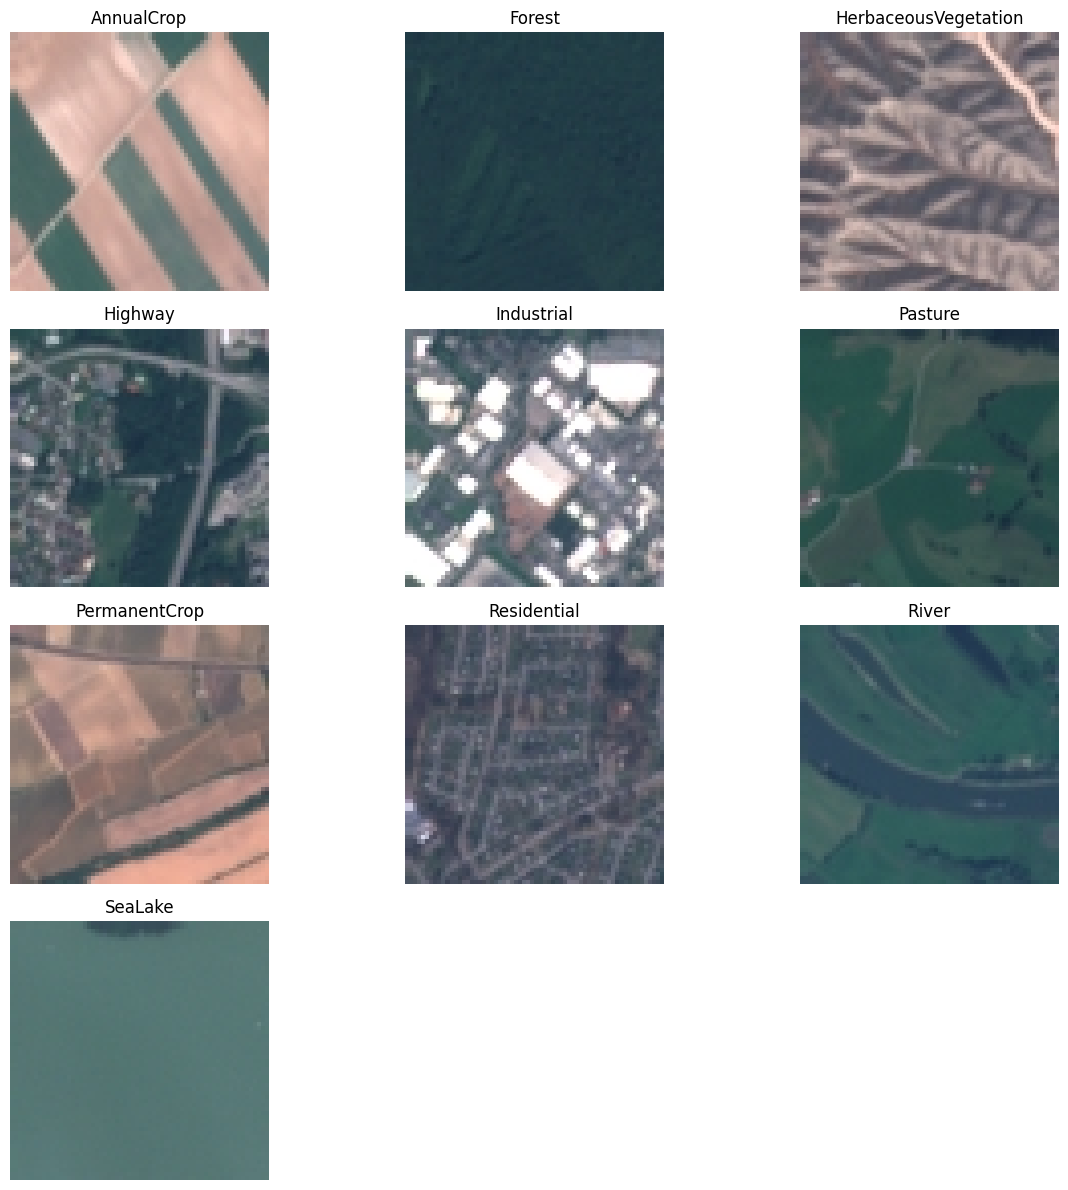

In [44]:
plt.figure(figsize=(12, 12))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    sample_img_name = os.listdir(class_path)[0]
    img = plt.imread(os.path.join(class_path, sample_img_name))
    plt.subplot(4, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [45]:
sample_batch, _ = next(iter(dataset))
print("Min pixel value:", np.min(sample_batch.numpy()))
print("Max pixel value:", np.max(sample_batch.numpy()))

Min pixel value: 26.0
Max pixel value: 255.0


In [46]:
len(dataset)

844

In [47]:
#splitting into train, validation and test
#80% for train
#20% - 10%  for validation and 10% for test

### Train/Val/Test Split

Can only do a two-way split in one call, so did it in two steps —
70/30 first, then split that 30% in half for val/test. Same seed both
times so nothing overlaps.

In [48]:
dataset_path = 'EuroSAT'   # or '/content/EuroSAT' depending on where it unzipped

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset='training',
    seed=42,
    image_size=(64, 64),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset='validation',
    seed=42,
    image_size=(64, 64),
    batch_size=32
)

temp_batches = len(temp_ds)
val_ds  = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))
print("Test batches:", len(test_ds))

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Train batches: 591
Val batches: 127
Test batches: 127


In [49]:
#data normalization
normalize = lambda x, y: (x / 255.0, y)

train_ds = train_ds.map(normalize)
val_ds   = val_ds.map(normalize)
test_ds  = test_ds.map(normalize)

In [50]:
#model creation
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPool2D(pool_size=(2, 2), strides = 2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPool2D(pool_size=(2, 2), strides = 2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPool2D(pool_size=(2, 2), strides = 2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile( optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,106 (2.64 MB)

 Trainable params: 692,106 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4866 - loss: 1.3014 - val_accuracy: 0.6887 - val_loss: 0.8516
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7218 - loss: 0.7710 - val_accuracy: 0.7761 - val_loss: 0.6269
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7729 - loss: 0.6274 - val_accuracy: 0.7847 - val_loss: 0.6131
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8075 - loss: 0.5418 - val_accuracy: 0.7928 - val_loss: 0.5775
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8284 - loss: 0.4778 - val_accuracy: 0.8059 - val_loss: 0.5649
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8499 - loss: 0.4166 - val_accuracy: 0.8250 - val_loss: 0.4919
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8734 - loss: 0.3588 - val_accuracy: 0.8260 - val_loss: 0.5036
Epoch 8/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8869 - loss: 0.3139 - val_accurac

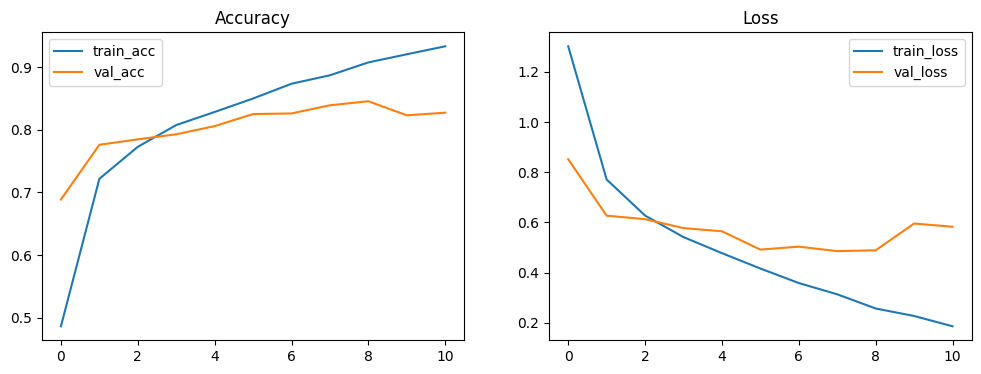

In [52]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.show()

In [53]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8256 - loss: 0.5185
Test Loss: 0.5184809565544128
Test Accuracy: 0.8255698680877686


                      precision    recall  f1-score   support

          AnnualCrop       0.83      0.88      0.86       431
              Forest       0.99      0.88      0.93       460
HerbaceousVegetation       0.76      0.74      0.75       429
             Highway       0.53      0.82      0.64       374
          Industrial       0.93      0.88      0.90       377
             Pasture       0.91      0.71      0.80       265
       PermanentCrop       0.79      0.58      0.67       381
         Residential       0.94      0.96      0.95       432
               River       0.80      0.77      0.79       414
             SeaLake       0.92      0.96      0.94       473

            accuracy                           0.83      4036
           macro avg       0.84      0.82      0.82      4036
        weighted avg       0.84      0.83      0.83      4036



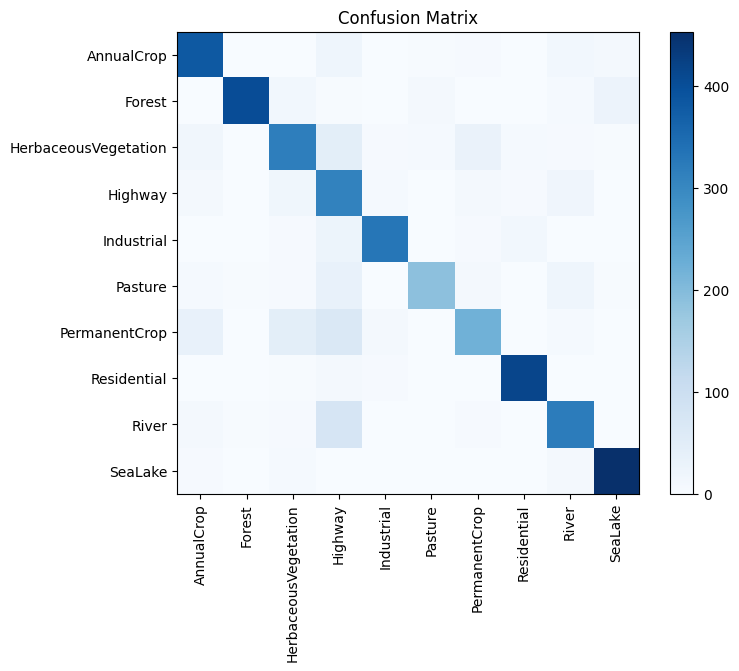

In [54]:
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    predicted_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.xticks(range(10), class_names, rotation=90)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.title('Confusion Matrix')
plt.show()

# **Transfer Learning using VGG16**

In [55]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten

In [56]:
#loading pretrained vgg16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base_model.trainable = False

In [57]:
#add custom layers
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
output_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

In [58]:
#compiling
model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [59]:
#training
history = model.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stop, checkpoint])

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.7773 - loss: 0.6462 - val_accuracy: 0.8516 - val_loss: 0.4545
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.8543 - loss: 0.4269 - val_accuracy: 0.8607 - val_loss: 0.4019
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8733 - loss: 0.3629 - val_accuracy: 0.8521 - val_loss: 0.4123
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8825 - loss: 0.3297 - val_accuracy: 0.8649 - val_loss: 0.3900
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.8973 - loss: 0.2957 - val_accuracy: 0.8799 - val_loss: 0.3593


In [60]:
test_loss, test_acc = model.evaluate(test_ds)
print("VGG16 Test Loss:", test_loss)
print("VGG16 Test Accuracy:", test_acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8707 - loss: 0.3791
VGG16 Test Loss: 0.37911081314086914
VGG16 Test Accuracy: 0.8706640005111694


In [61]:
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.88      0.89       442
              Forest       0.96      0.88      0.92       442
HerbaceousVegetation       0.80      0.92      0.86       430
             Highway       0.84      0.71      0.77       373
          Industrial       0.97      0.88      0.92       385
             Pasture       0.85      0.80      0.82       265
       PermanentCrop       0.78      0.82      0.80       381
         Residential       0.88      0.97      0.92       428
               River       0.79      0.84      0.81       419
             SeaLake       0.95      0.97      0.96       471

            accuracy                           0.87      4036
           macro avg       0.87      0.86      0.87      4036
        weighted avg       0.87      0.87      0.87      4036



### Custom CNN vs VGG16

| Model | Val Acc | Val Loss | Test Acc |
|---|---|---|---|
| Custom CNN | ~82% | ~0.50 | 84.76% |
| VGG16 | 87.5% | 0.39 | *(add after test eval)* |

VGG16 pulled ahead even with just 5 epochs frozen — pretrained features
clearly help. Same weak classes (Highway/River/PermanentCrop) showed up
in both models, so it's a resolution/similarity issue, not a training one.

In [62]:
import os
print(os.path.exists('best_model.keras'))

True


In [63]:
from google.colab import files
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>